# Milestone 1 Benchmark Visualizations

This notebook visualizes the single-thread benchmark results from `benchmarks/full_benchmark_single_thread.py` for the three model families discussed in `MILESTONE_1.md`: Qwen2.5-VL, InternVL2.5, and LLaVA-Next.

The runtime charts compare legacy, fast, and the InternVL2.5 manual card preprocessing path. The memory charts use peak RSS from `benchmarks/full_memory_benchmark_single_thread.py --skip-warmup`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == "visualizations" else Path.cwd() / "visualizations"
FIG_DIR = NOTEBOOK_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

models = ["Qwen2.5-VL", "InternVL2.5", "LLaVA-Next"]
implementations = ["Legacy", "Fast"]

# Median batch runtime in milliseconds.
runtime_ms = {
    "W3 randomized images": {
        "Qwen2.5-VL": {"Legacy": 1721.83, "Fast": 1345.19},
        "InternVL2.5": {"Legacy": 707.51, "Fast": 278.99, "Manual Card": 3307.82},
        "LLaVA-Next": {"Legacy": 1649.91, "Fast": 817.58},
    },
    "W4 A4-sized images": {
        "Qwen2.5-VL": {"Legacy": 11217.60, "Fast": 11671.59},
        "InternVL2.5": {"Legacy": 1373.90, "Fast": 1200.34, "Manual Card": 2516.35},
        "LLaVA-Next": {"Legacy": 2494.60, "Fast": 570.86},
    },
}

# Peak RSS in megabytes from benchmarks/full_memory_benchmark_single_thread.py --skip-warmup.
peak_rss_mb = {
    "W3 randomized images": {
        "Qwen2.5-VL": {"Legacy": 851.29, "Fast": 794.49},
        "InternVL2.5": {"Legacy": 77.08, "Fast": 103.44, "Manual Card": 1106.72},
        "LLaVA-Next": {"Legacy": 532.36, "Fast": 582.25},
    },
    "W4 A4-sized images": {
        "Qwen2.5-VL": {"Legacy": 3409.17, "Fast": 6388.97},
        "InternVL2.5": {"Legacy": 136.15, "Fast": 400.07, "Manual Card": 159.23},
        "LLaVA-Next": {"Legacy": 218.09, "Fast": 290.96},
    },
}

colors = {"Legacy": "#4C78A8", "Fast": "#F58518", "Manual Card": "#54A24B"}
runtime_implementations = {
    "Qwen2.5-VL": ["Legacy", "Fast"],
    "InternVL2.5": ["Legacy", "Fast", "Manual Card"],
    "LLaVA-Next": ["Legacy", "Fast"],
}
memory_implementations = {
    "Qwen2.5-VL": ["Legacy", "Fast"],
    "InternVL2.5": ["Legacy", "Fast", "Manual Card"],
    "LLaVA-Next": ["Legacy", "Fast"],
}

In [2]:
def annotate_bars(ax, bars, fmt="{:.0f}", rotation=0):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            fmt.format(height),
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            rotation=rotation,
        )


def plot_variable_grouped_bars(data, workload, implementation_map, ylabel, title, filename, value_fmt="{:.0f}"):
    x = np.arange(len(models))
    width = 0.22

    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    legend_labels = []
    for model_index, model in enumerate(models):
        impls = implementation_map[model]
        offsets = (np.arange(len(impls)) - (len(impls) - 1) / 2) * width
        for offset, impl in zip(offsets, impls):
            bars = ax.bar(
                x[model_index] + offset,
                data[workload][model][impl],
                width,
                label=impl if impl not in legend_labels else None,
                color=colors[impl],
                edgecolor="white",
                linewidth=0.8,
            )
            annotate_bars(ax, bars, value_fmt)
            legend_labels.append(impl)

    ax.set_title(title, fontsize=15, pad=14)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend(frameon=True)
    ax.margins(y=0.18)
    ax.spines[["top", "right"]].set_visible(False)

    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=200, bbox_inches="tight")
    return fig, ax

## W3 Runtime: Randomized 256-1048 px Images

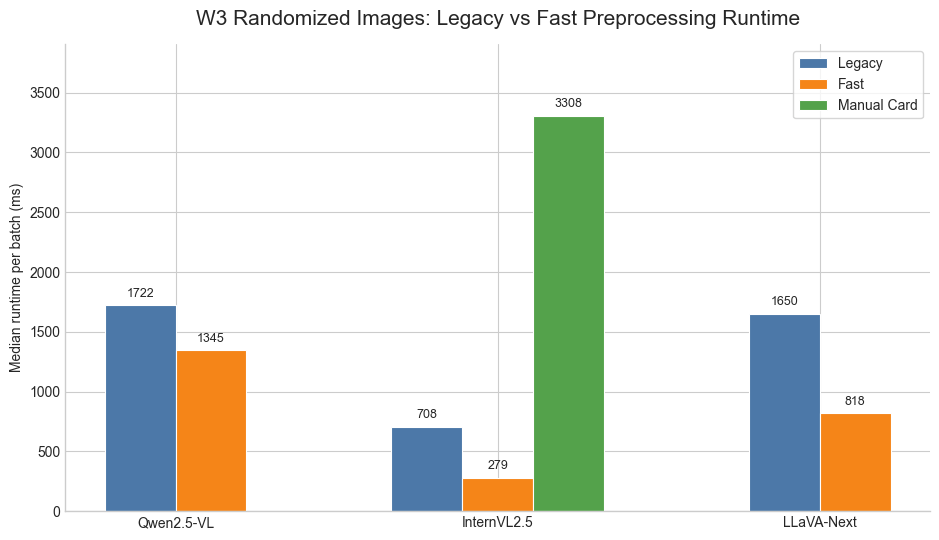

In [3]:
plot_variable_grouped_bars(
    runtime_ms,
    "W3 randomized images",
    runtime_implementations,
    ylabel="Median runtime per batch (ms)",
    title="W3 Randomized Images: Legacy vs Fast Preprocessing Runtime",
    filename="w3_runtime_legacy_vs_fast.png",
);

## W4 Runtime: A4-Sized Images

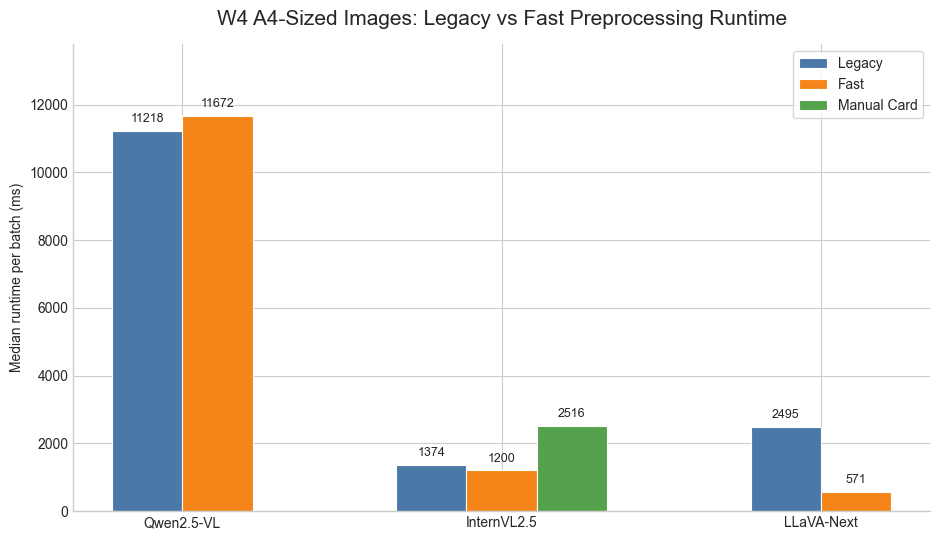

In [4]:
plot_variable_grouped_bars(
    runtime_ms,
    "W4 A4-sized images",
    runtime_implementations,
    ylabel="Median runtime per batch (ms)",
    title="W4 A4-Sized Images: Legacy vs Fast Preprocessing Runtime",
    filename="w4_runtime_legacy_vs_fast.png",
);

## W3 Peak Memory Allocation

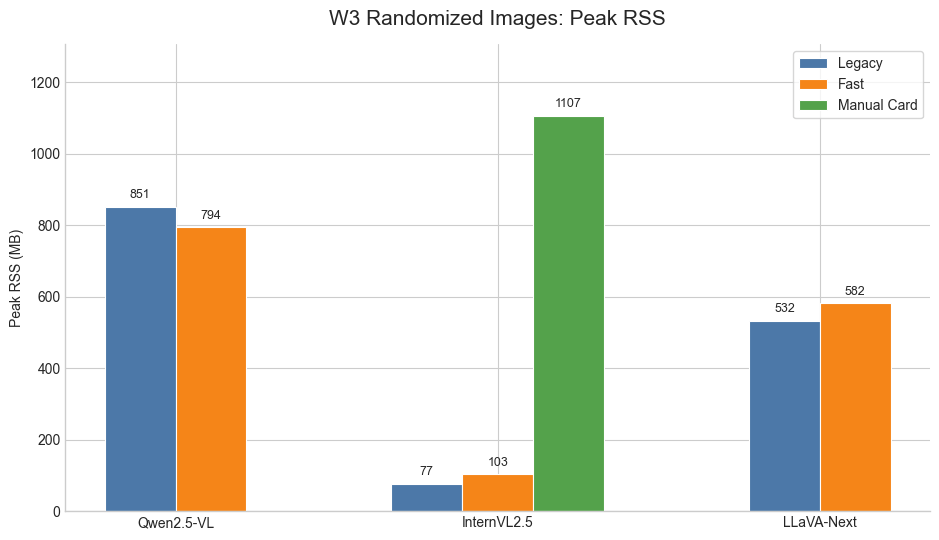

In [5]:
plot_variable_grouped_bars(
    peak_rss_mb,
    "W3 randomized images",
    memory_implementations,
    ylabel="Peak RSS (MB)",
    title="W3 Randomized Images: Peak RSS",
    filename="w3_peak_rss_legacy_fast_manual.png",
);

## W4 Peak Memory Allocation

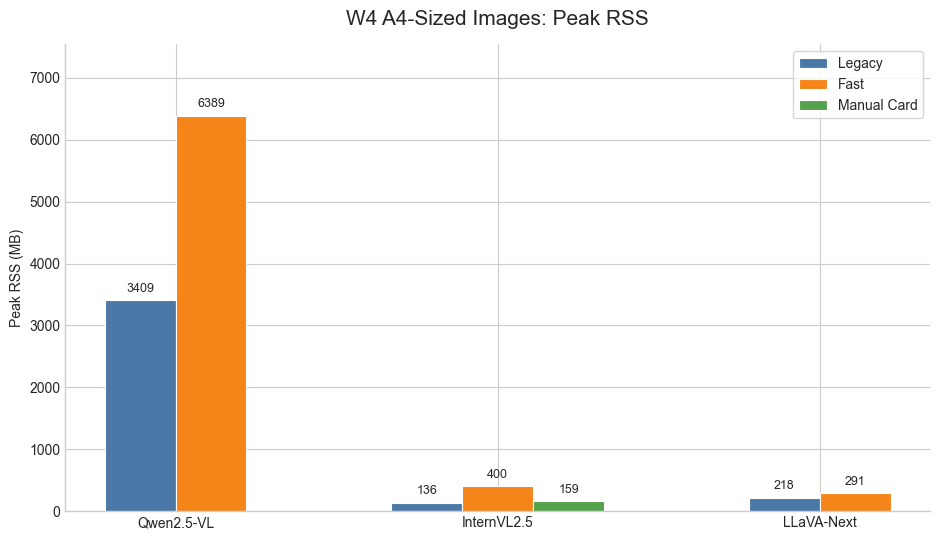

In [6]:
plot_variable_grouped_bars(
    peak_rss_mb,
    "W4 A4-sized images",
    memory_implementations,
    ylabel="Peak RSS (MB)",
    title="W4 A4-Sized Images: Peak RSS",
    filename="w4_peak_rss_legacy_fast_manual.png",
);

In [7]:
for old_name in [
    "peak_memory_legacy_vs_fast.png",
    "w3_peak_memory_legacy_fast_manual.png",
    "w4_peak_memory_legacy_fast_manual.png",
]:
    old_path = FIG_DIR / old_name
    if old_path.exists():
        old_path.unlink()

## Quick Takeaways

- W3 shows that fast preprocessing improves all three comparable Hugging Face paths, while InternVL2.5 manual card preprocessing is much slower on randomized images.
- W4 is more mixed: LLaVA-Next benefits strongly from the fast path, InternVL2.5 fast improves modestly over legacy and manual card, and Qwen2.5-VL fast is slightly slower than legacy on this workload.
- Peak RSS suggests substantial intermediate buffering for Qwen2.5-VL, especially on W4. InternVL2.5 now shows legacy, fast, and manual card memory paths.